# Notebook 3 — Redes Adversárias Generativas (GANs)

Duas redes em competição (Goodfellow et al., 2014):

- o **gerador** $G$ — o falsificador: transforma ruído em imagens;
- o **discriminador** $D$ — o perito: decide se uma imagem é real ou falsa.

$G$ tenta enganar $D$; $D$ tenta não ser enganado. O equilíbrio desse jogo produz um gerador convincente.

## 0. Preparação do ambiente

Este notebook roda **localmente** e no **Google Colab**. A célula abaixo é só infraestrutura: ela garante o módulo de apoio `aula_generativa.py` (carregamento de dados, gráficos e a "cirurgia" na VGG ficam lá, fora do foco da aula). No Colab a célula aparece **recolhida** — basta executá-la e seguir em frente.


In [1]:
# >>> infra-colab-aula-generativa >>>
#@title ⚙️ Infraestrutura: módulo de apoio (execute e siga em frente) { display-mode: "form" }
import os
_APOIO = r'''

# -*- coding: utf-8 -*-
"""
Biblioteca de apoio da Aula Generativa (Encoder-Decoder, Style Transfer e GANs).

Tudo o que NÃO é o tópico central da aula (carregamento de dados, plotagem,
montagem do modelo VGG para style transfer, downloads) fica abstraído aqui,
para que os notebooks tenham apenas células pequenas e didáticas.
"""

import os
import urllib.request

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

import torchvision
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

# ----------------------------------------------------------------------
# Dispositivo e reprodutibilidade
# ----------------------------------------------------------------------

def dispositivo():
    """Retorna o melhor dispositivo disponível (MPS no Apple Silicon, CUDA ou CPU)."""
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def semente(seed=42):
    """Fixa a semente aleatória para reduzir a variabilidade entre execuções.

    `torch.manual_seed` já cobre CPU, CUDA e MPS, além do embaralhamento do
    DataLoader. (Em GPU, o cuDNN ainda pode introduzir pequena não-determinância.)
    """
    torch.manual_seed(seed)
    np.random.seed(seed)


# ----------------------------------------------------------------------
# Dados
# ----------------------------------------------------------------------

_DATA_DIR = os.path.join(os.path.dirname(os.path.abspath(__file__)), "_data")


def carregar_mnist(batch_size=128, n_amostras=None, normalizar_11=False):
    """DataLoader do MNIST.

    normalizar_11=True deixa os pixels em [-1, 1] (necessário para a GAN,
    cujo gerador termina em Tanh). Caso contrário, pixels em [0, 1].
    """
    if normalizar_11:
        tf = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.5,), (0.5,))])
    else:
        tf = transforms.ToTensor()
    ds = datasets.MNIST(root=_DATA_DIR, train=True, download=True, transform=tf)
    if n_amostras is not None:
        ds = Subset(ds, range(n_amostras))
    return DataLoader(ds, batch_size=batch_size, shuffle=True)


# ----------------------------------------------------------------------
# Visualização
# ----------------------------------------------------------------------

def mostrar_grade(imgs, titulo=None, n=8, desnormalizar=False):
    """Mostra um lote de imagens em grade. Aceita tensor (B, C, H, W)."""
    imgs = imgs.detach().cpu()[:n * n]
    if desnormalizar:
        imgs = imgs / 2 + 0.5
    grade = torchvision.utils.make_grid(imgs, nrow=n, padding=2)
    plt.figure(figsize=(7, 7))
    plt.imshow(np.transpose(grade.clamp(0, 1).numpy(), (1, 2, 0)))
    plt.axis("off")
    if titulo:
        plt.title(titulo)
    plt.show()


def comparar_linhas(linhas, titulos, n=8):
    """Mostra listas de imagens em linhas comparáveis (ex.: original x reconstruída)."""
    fig, axes = plt.subplots(len(linhas), n, figsize=(1.3 * n, 1.5 * len(linhas)))
    for i, (lote, titulo) in enumerate(zip(linhas, titulos)):
        lote = lote.detach().cpu()
        for j in range(n):
            ax = axes[i, j] if len(linhas) > 1 else axes[j]
            ax.imshow(lote[j].squeeze().clamp(0, 1).numpy(), cmap="gray")
            ax.axis("off")
            if j == 0:
                ax.set_title(titulo, loc="left", fontsize=10)
    plt.tight_layout()
    plt.show()


def curva(valores, xlabel="época", ylabel="perda", titulo=None, rotulos=None):
    """Plota uma ou mais curvas de treinamento."""
    if not valores:
        return
    plt.figure(figsize=(6, 3.5))
    if isinstance(valores[0], (list, tuple, np.ndarray)):
        for serie, rot in zip(valores, rotulos or [None] * len(valores)):
            plt.plot(serie, label=rot)
        if rotulos:
            plt.legend()
    else:
        plt.plot(valores)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if titulo:
        plt.title(titulo)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def ruido(imgs, intensidade=0.5):
    """Adiciona ruído gaussiano a um lote de imagens em [0, 1]."""
    return (imgs + intensidade * torch.randn_like(imgs)).clamp(0, 1)


def interpolar_latente(decoder, z1, z2, passos=10):
    """Decodifica interpolações lineares entre dois vetores latentes.

    `decoder` pode ser o decoder do autoencoder ou o gerador G de uma GAN.
    z1, z2 têm forma (1, dim_latente) — ou (1, dim, 1, 1) para geradores
    convolucionais; o reshape de alfas se adapta à dimensionalidade de z.
    """
    alfas = torch.linspace(0, 1, passos, device=z1.device).view([-1] + [1] * (z1.dim() - 1))
    zs = (1 - alfas) * z1 + alfas * z2
    with torch.no_grad():
        return decoder(zs).cpu()


# ----------------------------------------------------------------------
# Imagens para Style Transfer
# ----------------------------------------------------------------------

_IMG_DIR = os.path.join(os.path.dirname(os.path.abspath(__file__)), "_imagens")

_URLS_EXEMPLO = {
    "conteudo.jpg": [
        # Neckarfront de Tübingen (a foto do artigo original de Gatys) e tartaruga (Wikimedia Commons)
        "https://commons.wikimedia.org/wiki/Special:FilePath/Tuebingen_Neckarfront.jpg?width=1024",
        "https://commons.wikimedia.org/wiki/Special:FilePath/Green_Sea_Turtle_grazing_seagrass.jpg?width=1024",
    ],
    "estilo.jpg": [
        # A Noite Estrelada, van Gogh (domínio público)
        "https://commons.wikimedia.org/wiki/Special:FilePath/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg?width=1024",
        "https://commons.wikimedia.org/wiki/Special:FilePath/The_Great_Wave_off_Kanagawa.jpg?width=1024",
    ],
}


def baixar_imagens_exemplo():
    """Baixa uma imagem de conteúdo e uma de estilo (Wikimedia Commons).

    Retorna (caminho_conteudo, caminho_estilo). Se os arquivos já existem,
    não baixa de novo.
    """
    os.makedirs(_IMG_DIR, exist_ok=True)
    caminhos = []
    for nome, urls in _URLS_EXEMPLO.items():
        destino = os.path.join(_IMG_DIR, nome)
        if not os.path.exists(destino):
            for url in urls:
                try:
                    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
                    with urllib.request.urlopen(req, timeout=30) as r, open(destino, "wb") as f:
                        f.write(r.read())
                    break
                except Exception as e:
                    print(f"Falha em {url[:60]}...: {e}")
        if not os.path.exists(destino):
            raise RuntimeError(
                f"Não foi possível baixar '{nome}'. Verifique a conexão ou copie "
                f"uma imagem manualmente para a pasta {_IMG_DIR}/."
            )
        caminhos.append(destino)
    return tuple(caminhos)


def carregar_imagem(caminho, tamanho=256, device=None):
    """Carrega uma imagem como tensor (1, 3, tamanho, tamanho) em [0, 1].

    Redimensiona para um quadrado `tamanho`x`tamanho`: conteúdo e estilo
    precisam ter a MESMA forma, porque os módulos de perda inseridos na VGG
    (ver `montar_modelo_estilo`) são atravessados pelas duas imagens. A leve
    distorção de proporção é aceitável para a demonstração.
    """
    tf = transforms.Compose([
        transforms.Resize((tamanho, tamanho)),
        transforms.ToTensor(),
    ])
    img = Image.open(caminho).convert("RGB")
    t = tf(img).unsqueeze(0)
    return t.to(device) if device is not None else t


def mostrar_imagens(tensores, titulos=None, figsize=(12, 5)):
    """Mostra lado a lado uma lista de tensores-imagem (1, 3, H, W)."""
    fig, axes = plt.subplots(1, len(tensores), figsize=figsize)
    if len(tensores) == 1:
        axes = [axes]
    for ax, t, titulo in zip(axes, tensores, titulos or [None] * len(tensores)):
        ax.imshow(t[0].detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy())
        ax.axis("off")
        if titulo:
            ax.set_title(titulo)
    plt.tight_layout()
    plt.show()


# ----------------------------------------------------------------------
# Montagem do modelo VGG para Style Transfer
# (a "cirurgia" na VGG fica abstraída aqui; as perdas ficam no notebook)
# ----------------------------------------------------------------------

_VGG_MEAN = torch.tensor([0.485, 0.456, 0.406])
_VGG_STD = torch.tensor([0.229, 0.224, 0.225])


class _Normalizacao(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.mean = _VGG_MEAN.view(-1, 1, 1).to(device)
        self.std = _VGG_STD.view(-1, 1, 1).to(device)

    def forward(self, img):
        return (img - self.mean) / self.std


def montar_modelo_estilo(classe_content_loss, classe_style_loss,
                         img_conteudo, img_estilo,
                         camadas_conteudo=("conv_4",),
                         camadas_estilo=("conv_1", "conv_2", "conv_3", "conv_4", "conv_5"),
                         device=None):
    """Monta a VGG-19 truncada com módulos de perda inseridos.

    Recebe as CLASSES ContentLoss e StyleLoss definidas no notebook (elas são
    o conteúdo didático) e devolve (modelo, lista_style_losses, lista_content_losses).
    """
    device = device or img_conteudo.device
    # models.vgg19() já devolve uma instância nova, então não é preciso copiar.
    cnn = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).features.to(device).eval()

    modelo = nn.Sequential(_Normalizacao(device))
    perdas_estilo, perdas_conteudo = [], []

    i = 0
    for camada in cnn.children():
        if isinstance(camada, nn.Conv2d):
            i += 1
            nome = f"conv_{i}"
        elif isinstance(camada, nn.ReLU):
            nome = f"relu_{i}"
            camada = nn.ReLU(inplace=False)
        elif isinstance(camada, nn.MaxPool2d):
            nome = f"pool_{i}"
        else:
            raise RuntimeError(f"camada inesperada na VGG-19.features: {type(camada).__name__}")
        modelo.add_module(nome, camada)

        if nome in camadas_conteudo:
            alvo = modelo(img_conteudo).detach()
            perda = classe_content_loss(alvo)
            modelo.add_module(f"content_loss_{i}", perda)
            perdas_conteudo.append(perda)

        if nome in camadas_estilo:
            alvo = modelo(img_estilo).detach()
            perda = classe_style_loss(alvo)
            modelo.add_module(f"style_loss_{i}", perda)
            perdas_estilo.append(perda)

    # corta tudo que vem depois da última perda
    for j in range(len(modelo) - 1, -1, -1):
        if isinstance(modelo[j], (classe_content_loss, classe_style_loss)):
            break
    modelo = modelo[: j + 1]

    modelo.requires_grad_(False)
    return modelo, perdas_estilo, perdas_conteudo


# ----------------------------------------------------------------------
# Apoio às GANs
# ----------------------------------------------------------------------

def amostras_geradas(gerador, ruido_fixo, titulo=None):
    """Gera imagens a partir de um ruído fixo e as mostra em grade."""
    gerador.eval()
    with torch.no_grad():
        falsas = gerador(ruido_fixo).cpu()
    gerador.train()
    n = int(round(len(falsas) ** 0.5))  # grade quadrada a partir do tamanho do lote
    mostrar_grade(falsas, titulo=titulo, n=n, desnormalizar=True)


def treinar_gan(G, D, loader, epocas=3, dim_ruido=100, forma_ruido=None,
                lr=2e-4, device=None, ruido_fixo=None, mostrar_progresso=True):
    """Treina uma GAN com o MESMO loop adversarial visto no notebook.

    Útil para reaproveitar o loop com outras arquiteturas (ex.: DCGAN).
    forma_ruido: tupla extra do ruído, ex. (100, 1, 1) para geradores convolucionais.
    Retorna (perdas_D, perdas_G).

    Obs.: cada chamada cria otimizadores Adam novos (o estado/momento é zerado).
    Para *continuar* um treino, aumente `epocas` numa única chamada em vez de
    chamar a função repetidas vezes.
    """
    device = device or next(G.parameters()).device
    criterio = nn.BCELoss()
    otim_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    otim_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    forma = forma_ruido or (dim_ruido,)
    perdas_D, perdas_G = [], []

    for epoca in range(epocas):
        soma_D = soma_G = 0.0
        for reais, _ in loader:
            reais = reais.to(device)
            b = reais.size(0)
            uns = torch.ones(b, 1, device=device)
            zeros = torch.zeros(b, 1, device=device)

            # 1) treina o discriminador
            z = torch.randn(b, *forma, device=device)
            falsas = G(z)
            perda_D = criterio(D(reais).view(b, 1), uns) + \
                      criterio(D(falsas.detach()).view(b, 1), zeros)
            otim_D.zero_grad(); perda_D.backward(); otim_D.step()

            # 2) treina o gerador
            perda_G = criterio(D(falsas).view(b, 1), uns)
            otim_G.zero_grad(); perda_G.backward(); otim_G.step()

            soma_D += perda_D.item(); soma_G += perda_G.item()

        perdas_D.append(soma_D / len(loader)); perdas_G.append(soma_G / len(loader))
        print(f"época {epoca + 1}/{epocas} | perda D: {perdas_D[-1]:.3f} | perda G: {perdas_G[-1]:.3f}")
        if mostrar_progresso and ruido_fixo is not None:
            amostras_geradas(G, ruido_fixo, titulo=f"Amostras após a época {epoca + 1}")

    return perdas_D, perdas_G
'''
with open("aula_generativa.py", "w", encoding="utf-8") as _f:
    _f.write(_APOIO)
print("aula_generativa.py garantido (versão da aula).")


aula_generativa.py garantido (versão da aula).


In [2]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
from torch import nn
try:
    import aula_generativa as ag
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "Execute primeiro a célula de infraestrutura (a primeira célula de código).")

device = ag.dispositivo()
ag.semente(42)
device

device(type='mps')

## 1. Dados reais

Pixels normalizados para $[-1, 1]$, porque a última camada do gerador é uma `Tanh`.

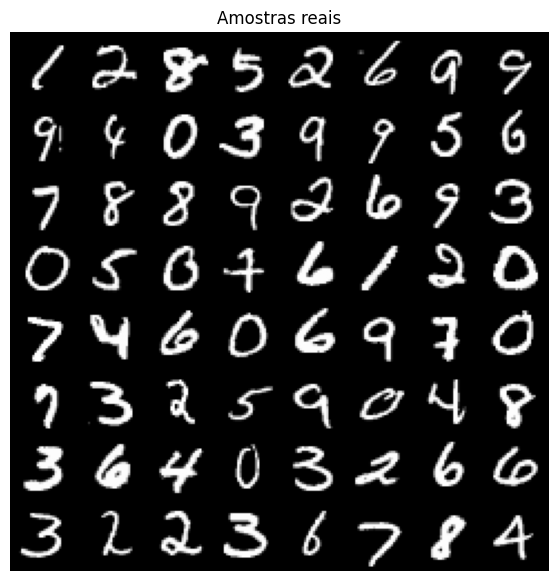

In [3]:
loader = ag.carregar_mnist(batch_size=128, normalizar_11=True)
reais, _ = next(iter(loader))
ag.mostrar_grade(reais, titulo="Amostras reais", desnormalizar=True)

## 2. O gerador: do ruído à imagem

Entrada: um vetor de ruído $z \in \mathbb{R}^{100}$. Saída: uma imagem 28×28.

In [4]:
DIM_RUIDO = 100

G = nn.Sequential(
    nn.Linear(DIM_RUIDO, 256), nn.ReLU(),
    nn.Linear(256, 512), nn.ReLU(),
    nn.Linear(512, 784), nn.Tanh(),
    nn.Unflatten(1, (1, 28, 28)),
).to(device)

Antes de treinar, o gerador produz apenas ruído (o mesmo `ruido_fixo` será usado ao longo do treino para acompanhar a evolução):

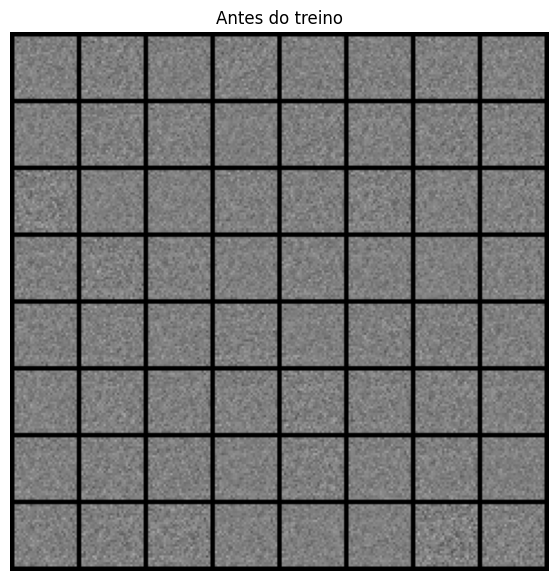

In [5]:
ruido_fixo = torch.randn(64, DIM_RUIDO, device=device)
ag.amostras_geradas(G, ruido_fixo, titulo="Antes do treino")

## 3. O discriminador: real ou falsa?

Um classificador binário comum: imagem $\to$ probabilidade de ser real.

In [6]:
D = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 512), nn.LeakyReLU(0.2),
    nn.Linear(512, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 1), nn.Sigmoid(),
).to(device)

## 4. O jogo adversarial

A perda é a entropia cruzada binária (BCE), usada de formas opostas:

- $D$ quer acertar: reais $\to 1$, falsas $\to 0$;
- $G$ quer que suas falsas recebam $1$.

In [7]:
criterio = nn.BCELoss()
otim_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
otim_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))

## 5. O loop de treinamento alternado

A cada lote, dois passos:

1. **treina $D$** com reais (rótulo 1) e falsas (rótulo 0) — o `detach()` congela $G$;
2. **treina $G$** para que $D$ classifique as falsas como reais — só os pesos de $G$ mudam.

época 1 | perda D: 0.858 | perda G: 1.511


época 2 | perda D: 0.439 | perda G: 3.003


época 3 | perda D: 0.372 | perda G: 3.737


época 4 | perda D: 0.410 | perda G: 3.463


época 5 | perda D: 0.304 | perda G: 3.930


...

época 16 | perda D: 0.694 | perda G: 2.470


época 17 | perda D: 0.765 | perda G: 2.411


época 18 | perda D: 0.774 | perda G: 1.818


época 19 | perda D: 0.832 | perda G: 1.724


época 20 | perda D: 0.859 | perda G: 1.637


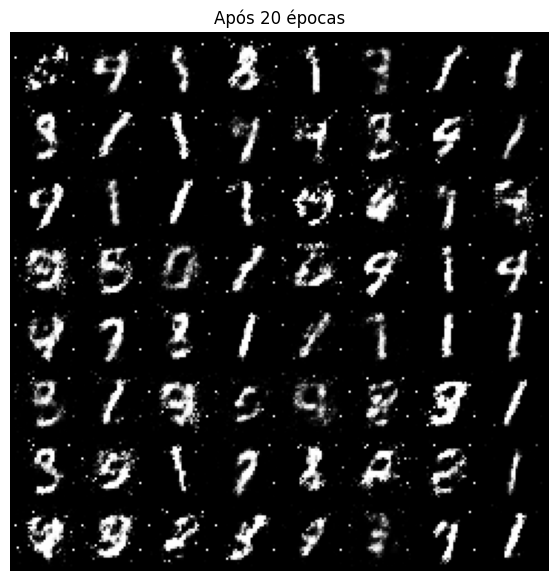

In [8]:
perdas_D, perdas_G = [], []

for epoca in range(20):
    soma_D, soma_G, n = 0.0, 0.0, 0
    for reais, _ in loader:
        reais = reais.to(device)
        b = reais.size(0)
        uns = torch.ones(b, 1, device=device)
        zeros = torch.zeros(b, 1, device=device)

        # passo 1: treina o discriminador (gerador parado)
        falsas = G(torch.randn(b, DIM_RUIDO, device=device))
        perda_D = criterio(D(reais), uns) + criterio(D(falsas.detach()), zeros)
        otim_D.zero_grad(); perda_D.backward(); otim_D.step()

        # passo 2: treina o gerador (discriminador parado)
        perda_G = criterio(D(falsas), uns)      # G quer que D diga "real"
        otim_G.zero_grad(); perda_G.backward(); otim_G.step()

        soma_D += perda_D.item(); soma_G += perda_G.item(); n += 1

    perdas_D.append(soma_D / n); perdas_G.append(soma_G / n)
    print(f"época {epoca + 1} | perda D: {perdas_D[-1]:.3f} | perda G: {perdas_G[-1]:.3f}")

ag.amostras_geradas(G, ruido_fixo, titulo="Após 20 épocas")

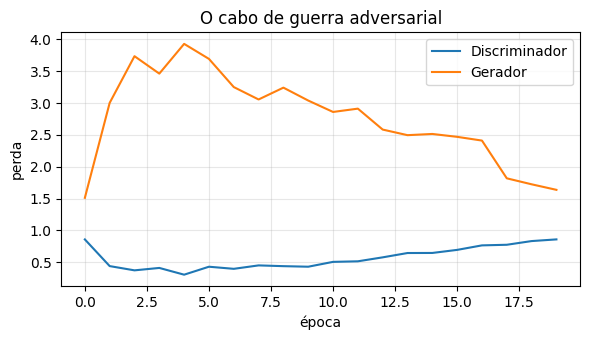

In [9]:
ag.curva([perdas_D, perdas_G], rotulos=["Discriminador", "Gerador"],
         titulo="O cabo de guerra adversarial")

## 6. DCGAN: a versão convolucional

Camadas densas ignoram a estrutura 2D da imagem. O DCGAN (Radford et al., 2015) usa **convoluções transpostas** para "crescer" a imagem: $1{\times}1 \to 7{\times}7 \to 14{\times}14 \to 28{\times}28$.

In [10]:
G_conv = nn.Sequential(
    nn.ConvTranspose2d(100, 128, 7, 1, 0), nn.BatchNorm2d(128), nn.ReLU(),
    nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),
    nn.ConvTranspose2d(64, 1, 4, 2, 1), nn.Tanh(),
).to(device)

D_conv = nn.Sequential(
    nn.Conv2d(1, 64, 4, 2, 1), nn.LeakyReLU(0.2),
    nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
    nn.Conv2d(128, 1, 7, 1, 0), nn.Sigmoid(),
).to(device)

O loop adversarial é **o mesmo** — muda apenas a forma do ruído, $(100, 1, 1)$. Por isso ele já está pronto na biblioteca:

época 1/10 | perda D: 0.447 | perda G: 3.291


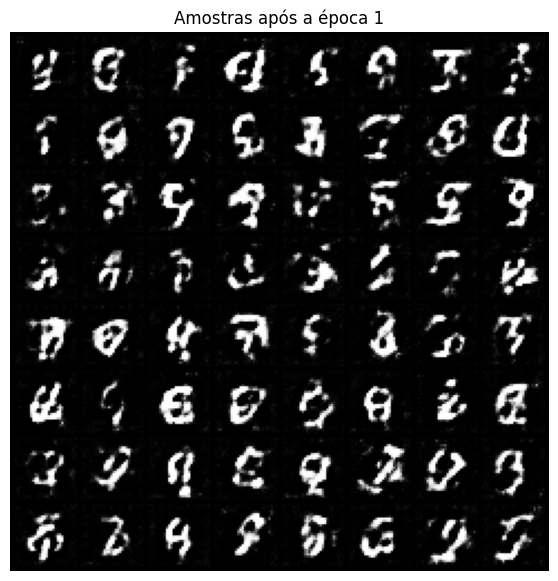

época 2/10 | perda D: 0.643 | perda G: 1.648


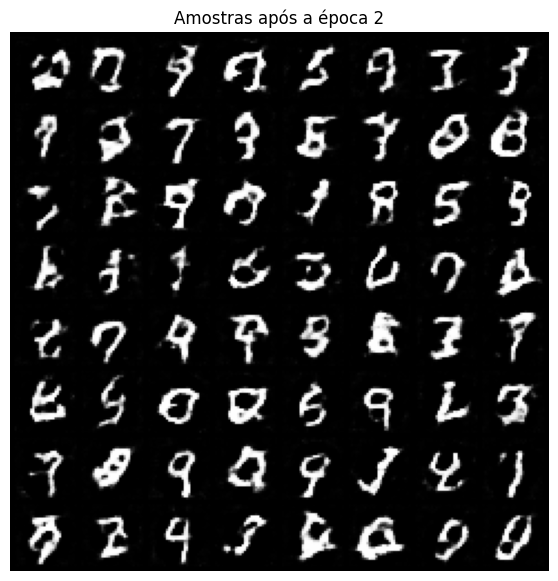

época 3/10 | perda D: 0.616 | perda G: 1.759


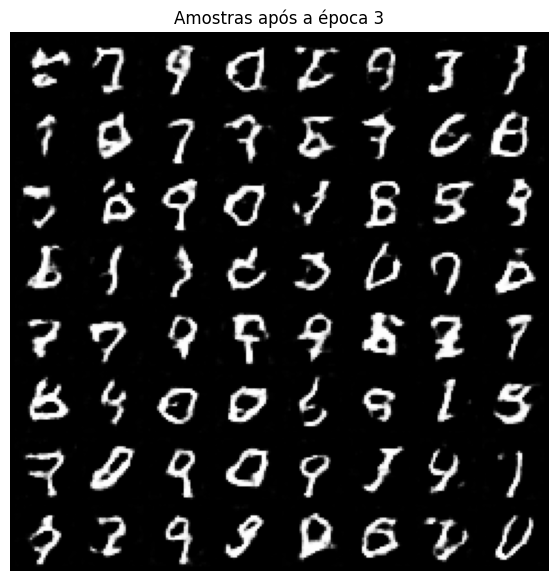

época 4/10 | perda D: 0.614 | perda G: 1.774


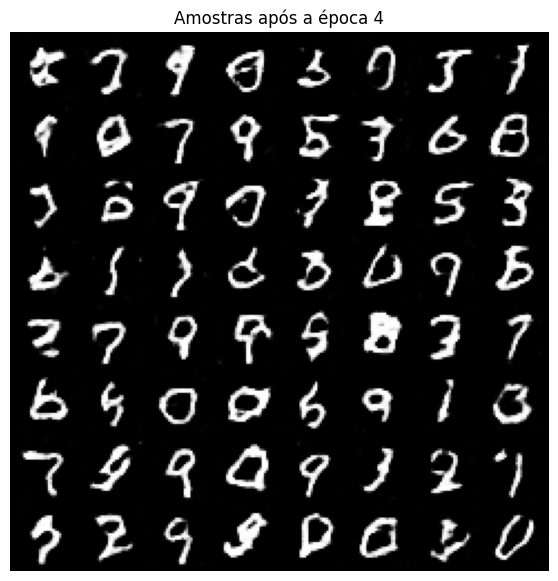

época 5/10 | perda D: 0.635 | perda G: 1.766


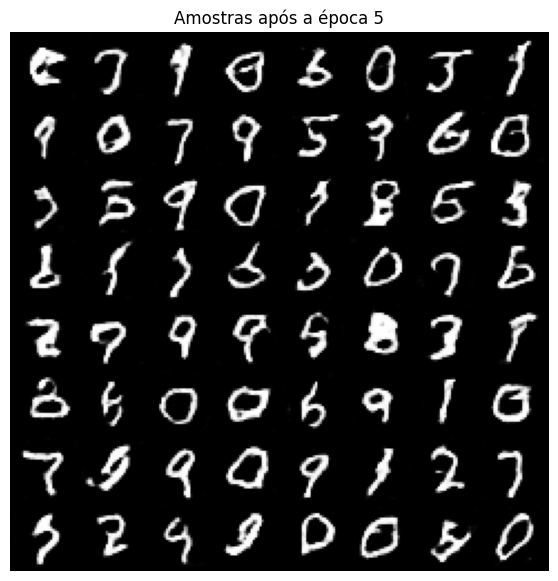

época 6/10 | perda D: 0.663 | perda G: 1.739


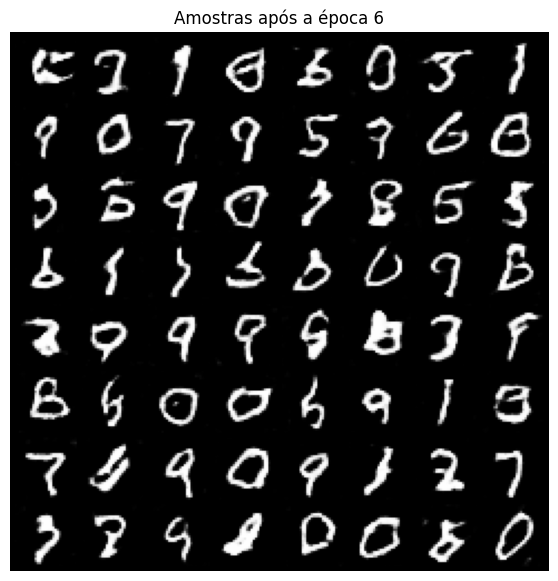

época 7/10 | perda D: 0.677 | perda G: 1.738


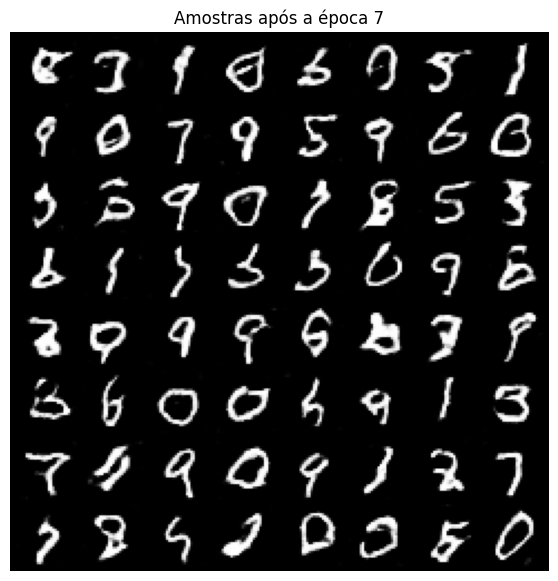

época 8/10 | perda D: 0.692 | perda G: 1.746


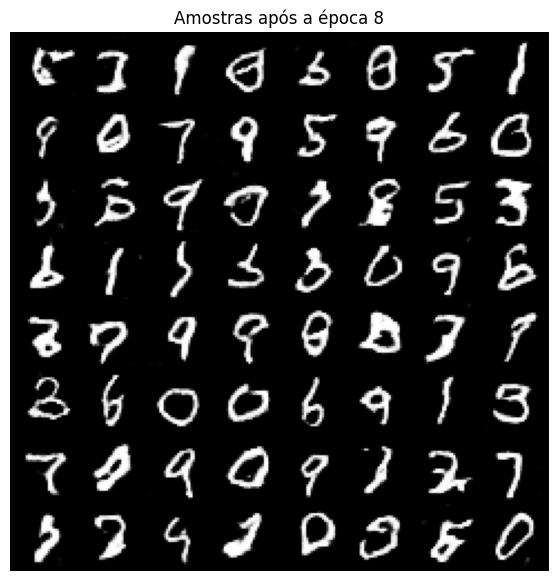

época 9/10 | perda D: 0.687 | perda G: 1.770


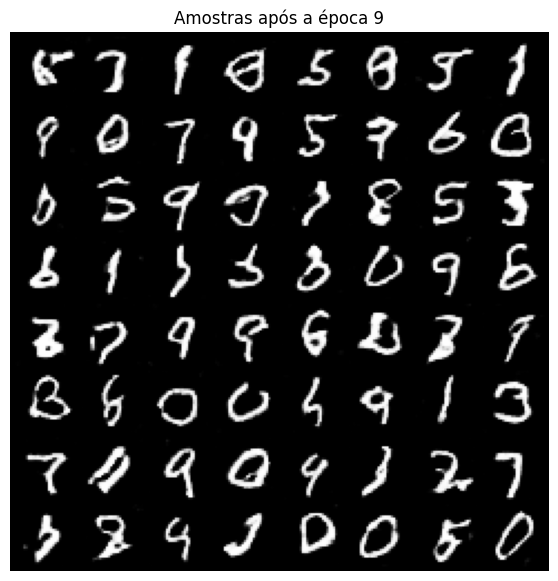

época 10/10 | perda D: 0.688 | perda G: 1.800


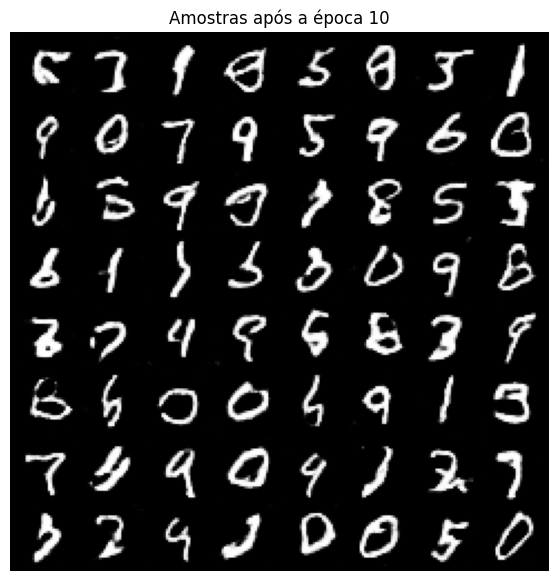

In [11]:
ruido_fixo_conv = torch.randn(64, 100, 1, 1, device=device)

perdas_D_conv, perdas_G_conv = ag.treinar_gan(
    G_conv, D_conv, loader, epocas=10,
    forma_ruido=(100, 1, 1), device=device,
    ruido_fixo=ruido_fixo_conv)

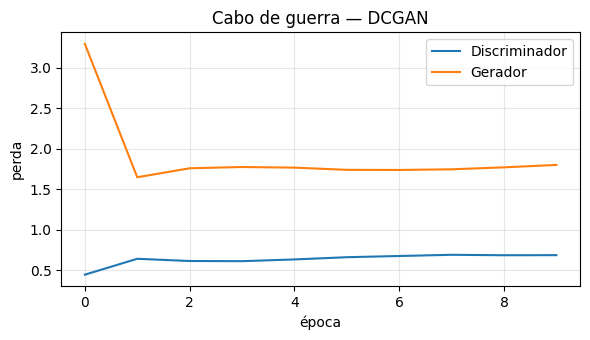

In [12]:
ag.curva([perdas_D_conv, perdas_G_conv], rotulos=["Discriminador", "Gerador"],
         titulo="Cabo de guerra — DCGAN")

## 7. O espaço de ruído também é um espaço latente

Interpolar entre dois ruídos $z_1 \to z_2$ gera transições suaves entre dígitos — assim como no autoencoder do Notebook 1.

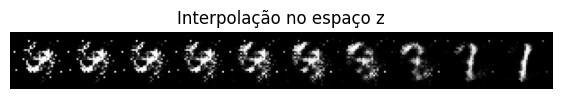

In [13]:
z1, z2 = torch.randn(1, DIM_RUIDO, device=device), torch.randn(1, DIM_RUIDO, device=device)
caminho = ag.interpolar_latente(G, z1, z2, passos=10)
ag.mostrar_grade(caminho, n=10, desnormalizar=True, titulo="Interpolação no espaço z")

## Exercícios

In [14]:
# TODO Exercício 1: continue o treinamento da GAN densa por mais 5 épocas
# (rode a célula do loop de novo). As amostras melhoram? Todos os dígitos
# aparecem, ou alguns dominam? (esse sintoma é o "mode collapse")

In [15]:
# TODO Exercício 2: aumente epocas= na chamada ag.treinar_gan (ex.: 20) e
# compare a nitidez das amostras com as da GAN densa. (Cada chamada cria
# otimizadores novos; para "continuar" o treino, aumente epocas numa só chamada.)

## Resumo e próximos passos

- Uma GAN é um **jogo de dois jogadores**: gerador (falsificador) × discriminador (perito).
- O treino alterna os dois passos; no equilíbrio ideal, $D$ acerta apenas 50%.
- Problemas clássicos: **gradientes que somem**, **mode collapse**, não-convergência — motivam variações como a perda de **Wasserstein**.
- **DCGAN** troca camadas densas por convoluções e melhora muito a qualidade.
- Variações famosas: GAN condicional, **pix2pix**, **CycleGAN**, super-resolução, *inpainting*.
- Demos para explorar: [pix2pix](https://affinelayer.com/pixsrv/) e [super-resolução](https://superresolution.streamlit.app/).
- Hoje, os **modelos de difusão** (DALL-E, Stable Diffusion) dominam a geração de imagens — mas o vocabulário (latente, gerador, adversarial) nasceu aqui.